**Sales Data Analysis Project**

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

*Data Load + Check*

In [4]:
df = pd.read_csv("data/newsales.csv")
df.head()

,OrderID,City,Product,Category,Quantity,Price
0,101,Mumbai,Laptop,Electronics,1.0,55000.0
1,102,Delhi,Mobile,Electronics,2.0,20000.0
2,103,Pune,Chair,Furniture,3.0,3000.0
3,104,Mumbai,Sofa,Furniture,NaN,25000.0
4,105,Bangalore,Headphones,Electronics,4.0,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   OrderID   10 non-null     int64  
 1   City      9 non-null      str    
 2   Product   10 non-null     str    
 3   Category  10 non-null     str    
 4   Quantity  9 non-null      float64
 5   Price     9 non-null      float64
dtypes: float64(2), int64(1), str(3)
memory usage: 612.0 bytes


In [6]:
df.describe()

,OrderID,Quantity,Price
count,10.00000,9.000000,9.000000
mean,105.50000,2.333333,23111.111111
std,3.02765,1.224745,20355.861837
min,101.00000,1.000000,2000.000000
25%,103.25000,1.000000,3000.000000
50%,105.50000,2.000000,20000.000000
75%,107.75000,3.000000,25000.000000
max,110.00000,4.000000,55000.000000


In [7]:
df.isnull()

,OrderID,City,Product,Category,Quantity,Price
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,True,False
4,False,False,False,False,False,True
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,True,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


*Missing values handle*

In [25]:
df["Quantity"]= df["Quantity"].fillna(5).astype(int)
df["Price"] = df["Price"].astype(int)


In [26]:
df

,OrderID,City,Product,Category,Quantity,Price
0,101,Mumbai,Laptop,Electronics,1,55000
1,102,Delhi,Mobile,Electronics,2,20000
2,103,Pune,Chair,Furniture,3,3000
3,104,Mumbai,Sofa,Furniture,5,25000
4,105,Bangalore,Headphones,Electronics,4,23111
5,106,Mumbai,Laptop,Electronics,1,55000
6,107,Delhi,Mobile,Electronics,2,20000
7,108,NaN,Chair,Furniture,3,3000
8,109,Pune,Sofa,Furniture,1,25000
9,110,Mumbai,Headphones,Electronics,4,2000


In [27]:
df.drop_duplicates()

,OrderID,City,Product,Category,Quantity,Price
0,101,Mumbai,Laptop,Electronics,1,55000
1,102,Delhi,Mobile,Electronics,2,20000
2,103,Pune,Chair,Furniture,3,3000
3,104,Mumbai,Sofa,Furniture,5,25000
4,105,Bangalore,Headphones,Electronics,4,23111
5,106,Mumbai,Laptop,Electronics,1,55000
6,107,Delhi,Mobile,Electronics,2,20000
7,108,NaN,Chair,Furniture,3,3000
8,109,Pune,Sofa,Furniture,1,25000
9,110,Mumbai,Headphones,Electronics,4,2000


*CREATING Revenue column*

In [29]:
df["Revenue"] = df["Quantity"] * df["Price"]
df

,OrderID,City,Product,Category,Quantity,Price,Revenue
0,101,Mumbai,Laptop,Electronics,1,55000,55000
1,102,Delhi,Mobile,Electronics,2,20000,40000
2,103,Pune,Chair,Furniture,3,3000,9000
3,104,Mumbai,Sofa,Furniture,5,25000,125000
4,105,Bangalore,Headphones,Electronics,4,23111,92444
5,106,Mumbai,Laptop,Electronics,1,55000,55000
6,107,Delhi,Mobile,Electronics,2,20000,40000
7,108,NaN,Chair,Furniture,3,3000,9000
8,109,Pune,Sofa,Furniture,1,25000,25000
9,110,Mumbai,Headphones,Electronics,4,2000,8000


In [30]:
total_revenue = df["Revenue"].sum()
print(total_revenue)

458444


City-wise Sales

In [31]:
df.groupby("City")["Revenue"].sum()

City
Bangalore     92444
Delhi         80000
Mumbai       243000
Pune          34000
Name: Revenue, dtype: int64

Top Selling Product

In [32]:
df.groupby("Product")["Quantity"].sum().idxmax()

'Headphones'

Category Performance

In [33]:
df.groupby("Category")["Revenue"].sum()

Category
Electronics    290444
Furniture      168000
Name: Revenue, dtype: int64

Highest Revenue City

In [34]:
df.groupby("City")["Revenue"].sum()

City
Bangalore     92444
Delhi         80000
Mumbai       243000
Pune          34000
Name: Revenue, dtype: int64

In [35]:
df["Sales_Tag"] = df["Revenue"].apply(lambda x: "High" if x > 20000 else "Low")

In [36]:
df

,OrderID,City,Product,Category,Quantity,Price,Revenue,Sales_Tag
0,101,Mumbai,Laptop,Electronics,1,55000,55000,High
1,102,Delhi,Mobile,Electronics,2,20000,40000,High
2,103,Pune,Chair,Furniture,3,3000,9000,Low
3,104,Mumbai,Sofa,Furniture,5,25000,125000,High
4,105,Bangalore,Headphones,Electronics,4,23111,92444,High
5,106,Mumbai,Laptop,Electronics,1,55000,55000,High
6,107,Delhi,Mobile,Electronics,2,20000,40000,High
7,108,NaN,Chair,Furniture,3,3000,9000,Low
8,109,Pune,Sofa,Furniture,1,25000,25000,High
9,110,Mumbai,Headphones,Electronics,4,2000,8000,Low


City-wise Revenue Chart

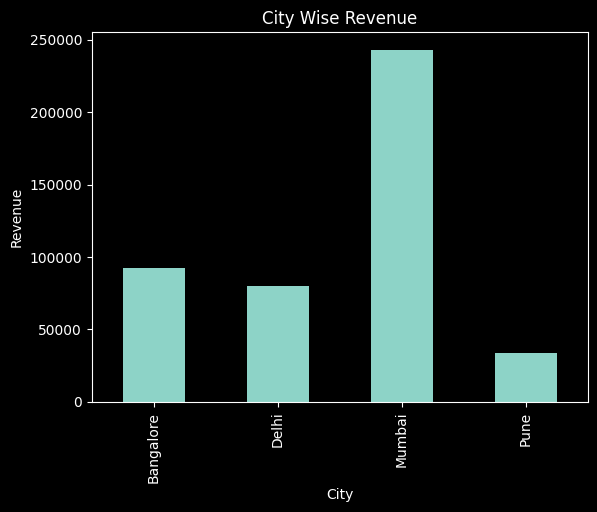

In [38]:
city_sales = df.groupby("City")["Revenue"].sum()

city_sales.plot(kind="bar")
plt.title("City Wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

Category-wise Revenue

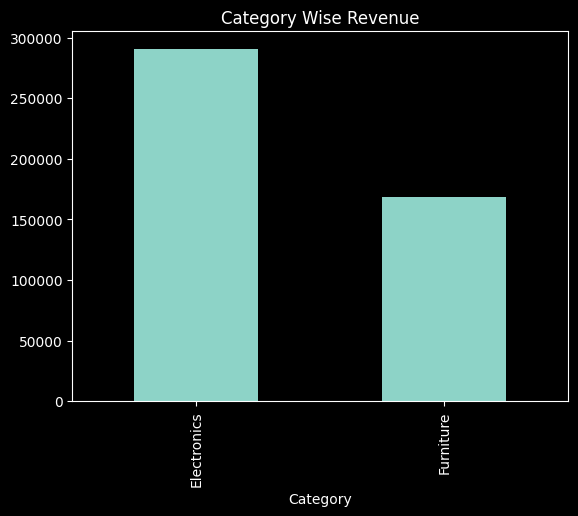

In [39]:
cat_sales = df.groupby("Category")["Revenue"].sum()

cat_sales.plot(kind="bar")
plt.title("Category Wise Revenue")
plt.show()

Top Products

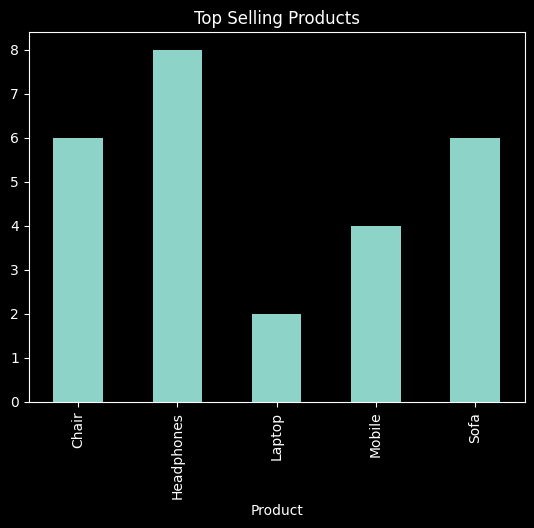

In [40]:
prod_sales = df.groupby("Product")["Quantity"].sum()

prod_sales.plot(kind="bar")
plt.title("Top Selling Products")
plt.show()